**Name:- Sarvesh Kulkarni**<br>
**Week:-5**

#import libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)


Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")


LSTM training completed


In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


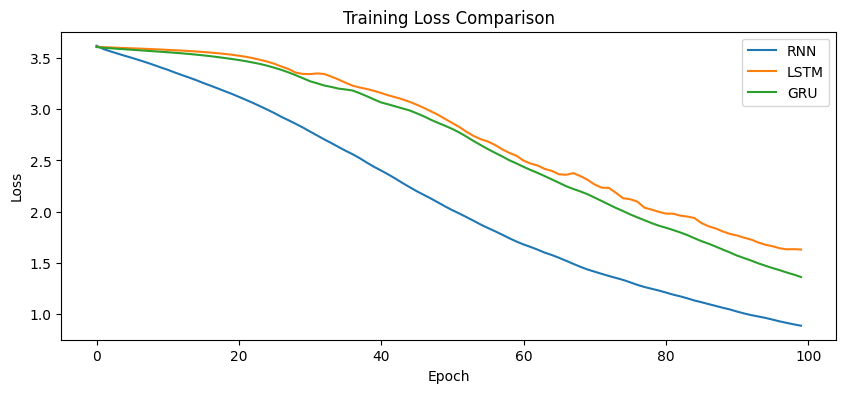

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text


In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))


RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is is can intelligence sentences
GRU : deep learning is faster and simpler lstm


# New text cortus Loaded

In [10]:
corpus = '''
It may appear that the students of Sanjivani College of Engineering are less active during HR or mentor sessions because they do not ask many questions.
However, this does not mean they are disengaged or uninterested.
In many cases, the questions that Sanjivani students have in mind are already asked by students from other colleges, so their doubts are answered without needing to repeat the same questions.
Additionally, the mentors provide detailed explanations beyond the questions asked, and Sanjivani students carefully note down these important points and maintain proper meeting notes for future reference.
The students attend the sessions with full attention and listen carefully throughout the discussions.
Their focus is on understanding the concepts rather than asking repetitive questions.
Therefore, judging their participation solely by the number of questions asked may not accurately reflect their level of engagement.
I strongly believe that the dedication, discipline, and learning attitude of the students from Sanjivani College of Engineering will help many of them earn Pre-Placement Offers (PPOs).
Their consistent effort and attentive participation during the internship demonstrate their commitment to learning and professional growth.
'''
print(corpus)



It may appear that the students of Sanjivani College of Engineering are less active during HR or mentor sessions because they do not ask many questions.
However, this does not mean they are disengaged or uninterested.
In many cases, the questions that Sanjivani students have in mind are already asked by students from other colleges, so their doubts are answered without needing to repeat the same questions. 
Additionally, the mentors provide detailed explanations beyond the questions asked, and Sanjivani students carefully note down these important points and maintain proper meeting notes for future reference.
The students attend the sessions with full attention and listen carefully throughout the discussions. 
Their focus is on understanding the concepts rather than asking repetitive questions. 
Therefore, judging their participation solely by the number of questions asked may not accurately reflect their level of engagement.
I strongly believe that the dedication, discipline, and lea

# Tokenization and Sequence Creation

In [11]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 119
X shape: (175, 30)
y shape: (175,)


# Updated vanila RNN

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=128,      # Increased embedding dimensions
        input_length=max_len - 1
    ),
    SimpleRNN(128),          # Increased hidden RNN units
    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0) #Increased epochs from 100 to 200
print("Vanilla RNN training completed")

Vanilla RNN training completed


# Updated LSTM

In [13]:
lstm_model = Sequential([
    Embedding(
        input_dim=total_words,
        output_dim=128,      # Increased embedding dimensions
        input_length=max_len - 1
    ),
    LSTM(128),               # Increased hidden LSTM units from 64 to 128
    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0) #Increased epochs from 100 to 200
print("LSTM training completed")

LSTM training completed


# Updated GRU

In [14]:
gru_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=128,      # Increased embedding dimensions
              input_length=max_len-1),
    GRU(128),  #Increased hidden GRU units
    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)  #Increased epochs from 100 to 200
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

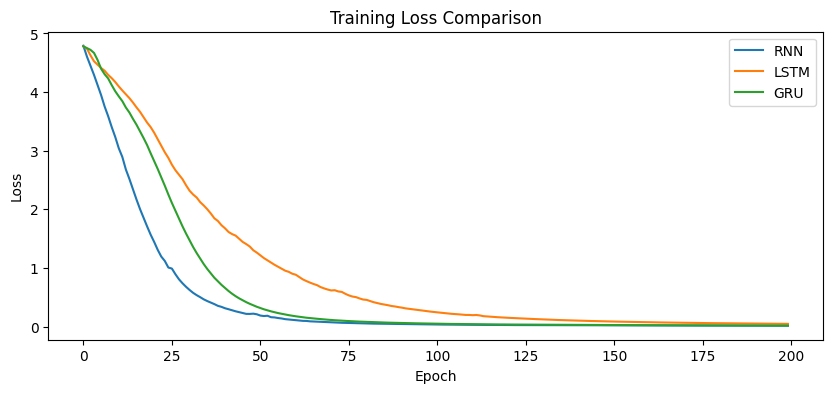

In [15]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [16]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text




Generate Text

In [17]:
#10  words generated
print("RNN :", generate_text(rnn_model, "In", 10))
print("LSTM:", generate_text(lstm_model, "In",10))
print("GRU :", generate_text(gru_model, "In", 10))

RNN : In many cases the questions that sanjivani students have in mind
LSTM: In many cases the questions that sanjivani students have in mind
GRU : In many cases the questions that sanjivani students have in mind


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**